In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# ==========================================
# 1. LOAD AND MAP THE DATA 
# ==========================================
df = pd.read_csv('final_results.csv')

rename_dict = {
    'Type_1_Original': 'QS',
    'Type_2_Agnostic': 'Slightly Abstract',     
    'Type_7_Agnostic_Simple': 'Moderately Abstract', 
    'Type_3_Degraded_10': 'Slightly Incomplete',  
    'Type_4_Degraded_30': 'Moderately Incomplete',
    'Type_5_Error_10': 'Slightly Incorrect',      
    'Type_6_Error_30': 'Moderately Incorrect'     
}
df['Clean Rubric'] = df['Rubric ID'].map(rename_dict)

# Calculate absolute error from Human Score first
df['AI Normalized (Out of 10)'] = abs(df['AI Normalized (Out of 10)'] - df['Human Normalized (Out of 10)'])
# --------------------

df_pivot = df.pivot_table(
    index=['Problem ID', 'Submission ID'], 
    columns='Clean Rubric', 
    values='AI Normalized (Out of 10)'
).reset_index()

altered_rubrics = [
    'Slightly Abstract', 'Moderately Abstract', 
    'Slightly Incomplete', 'Moderately Incomplete', 
    'Slightly Incorrect', 'Moderately Incorrect'
]

# Only calculate Diff (No final modulus)
for rubric in altered_rubrics:
    df_pivot[f'{rubric} (Diff)'] = df_pivot[rubric] - df_pivot['QS']

In [3]:
# ==========================================
# 2. THE PLOTTING ENGINE
# ==========================================
sns.set_theme(style="whitegrid")

def create_presentation_plot(columns_to_plot, title, plot_number):
    plt.figure(figsize=(14, 7)) # Slightly widened the figure to comfortably fit 6 categories
    
    plot_data = df_pivot.melt(
        id_vars=['Problem ID', 'Submission ID'], 
        value_vars=columns_to_plot,
        var_name='Deficiency Type', 
        value_name='Deviation'
    )
    
    sns.stripplot(x='Deficiency Type', y='Deviation', data=plot_data, hue='Deficiency Type',
                  palette='Set2', legend=False, jitter=True, alpha=0.7, size=6)
    
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Zero Error')
    
    categories = plot_data['Deficiency Type'].unique()
    for i, cat in enumerate(categories):
        cat_data = plot_data[plot_data['Deficiency Type'] == cat]['Deviation'].dropna()
        mean_val = cat_data.mean()
        median_val = cat_data.median()
        modes = cat_data.mode()
        mode_val = modes.iloc[0] if not modes.empty else 0
        
        stats_text = f"Mean: {mean_val:.2f}\nMed: {median_val:.2f}\nMode: {mode_val:.2f}"
        plt.text(i, 11.5, stats_text, horizontalalignment='center', size=10, 
                 color='black', weight='semibold', 
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))
    
    # Updated Title and Axis Labels
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("Deviation in grading prediction error compared to original rubric", fontsize=12)
    plt.xlabel("Rubrics with deficiencies introduced", fontsize=12)
    
    wrapped_labels = [textwrap.fill(cat.replace(' (Diff)', ''), width=15) for cat in categories]
    plt.xticks(range(len(categories)), wrapped_labels, fontsize=11)
    
    plt.ylim(-10.5, 14) 
    plt.yticks(range(-10, 11, 2)) 
    plt.tight_layout()
    
    # Save the file automatically
    filename = f"plot{plot_number}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    
    plt.show()

Saved: plot1.png


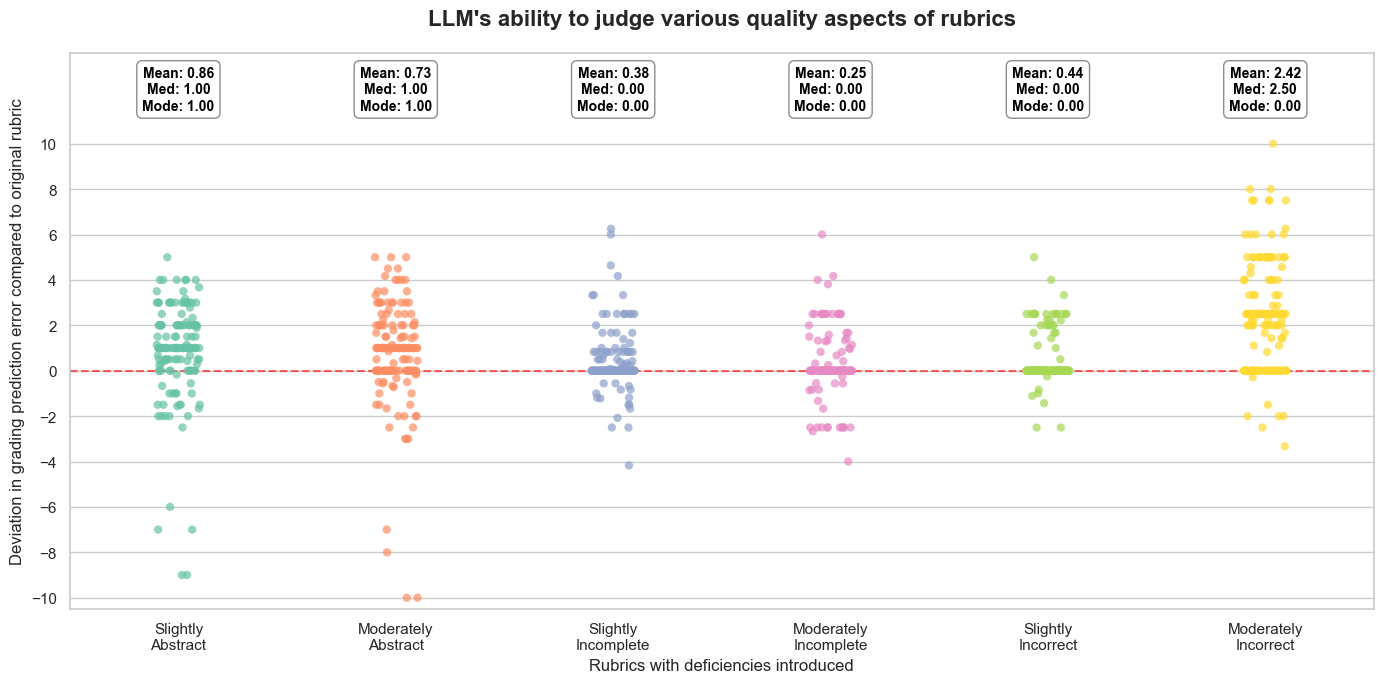

In [4]:
# ==========================================
# 3. GENERATE THE SINGLE MASTER PLOT
# ==========================================
create_presentation_plot(
    [
        'Slightly Abstract (Diff)', 
        'Moderately Abstract (Diff)', 
        'Slightly Incomplete (Diff)', 
        'Moderately Incomplete (Diff)', 
        'Slightly Incorrect (Diff)', 
        'Moderately Incorrect (Diff)'
    ], 
    "LLM's ability to judge various quality aspects of rubrics", 
    1
)